In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
np.random.seed(42)
n_samples = 500

sleep_hours = np.random.uniform(4, 9, n_samples)
screen_time = np.random.uniform(1, 8, n_samples)
work_hours = np.random.uniform(2, 10, n_samples)
breaks_taken = np.random.randint(0, 10, n_samples)
exercise_minutes = np.random.uniform(0, 90, n_samples)
caffeine_intake = np.random.randint(0, 6, n_samples)
distractions = np.random.randint(0, 15, n_samples)
mood_score = np.random.randint(1, 11, n_samples)

In [3]:
focus_score = (
    sleep_hours * 8 +
    work_hours * 5 +
    exercise_minutes * 0.3 +
    mood_score * 6 -
    screen_time * 6 -
    distractions * 4 -
    caffeine_intake * 2 +
    np.random.normal(0, 5, n_samples)
)

focus_score = np.clip(focus_score, 0, 100)

In [4]:
df = pd.DataFrame({
    "sleep_hours": sleep_hours,
    "screen_time": screen_time,
    "work_hours": work_hours,
    "breaks_taken": breaks_taken,
    "exercise_minutes": exercise_minutes,
    "caffeine_intake": caffeine_intake,
    "distractions": distractions,
    "mood_score": mood_score,
    "focus_score": focus_score
})

df.head()

,sleep_hours,screen_time,work_hours,breaks_taken,exercise_minutes,caffeine_intake,distractions,mood_score,focus_score
0,5.872701,5.887132,3.481063,1,18.363207,3,7,1,4.375699
1,8.753572,4.752675,6.335208,5,49.957645,4,7,5,90.340127
2,7.659970,3.166693,8.983567,4,65.976417,0,12,6,91.642978
3,6.993292,6.696565,7.857799,9,55.438691,0,5,8,100.000000
4,4.780093,5.793118,8.452489,8,16.922226,3,10,3,26.540533


In [5]:
df.describe()

,sleep_hours,screen_time,work_hours,breaks_taken,exercise_minutes,caffeine_intake,distractions,mood_score,focus_score
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,6.492809,4.373660,6.140465,4.43600,44.763108,2.518000,6.934000,5.51200,66.753192
std,1.493442,1.998454,2.377543,2.80243,25.532548,1.693343,4.276239,2.94537,27.690176
min,4.025308,1.032424,2.039520,0.00000,0.140859,0.000000,0.000000,1.00000,0.000000
25%,5.206398,2.603695,3.929824,2.00000,23.422913,1.000000,3.000000,3.00000,48.149524
50%,6.565819,4.302751,6.317907,4.00000,45.615510,3.000000,7.000000,6.00000,69.666372
75%,7.780624,6.084358,8.218750,7.00000,66.034733,4.000000,10.000000,8.00000,91.447641
max,8.964824,7.998024,9.995310,9.00000,89.851276,5.000000,14.000000,10.00000,100.000000


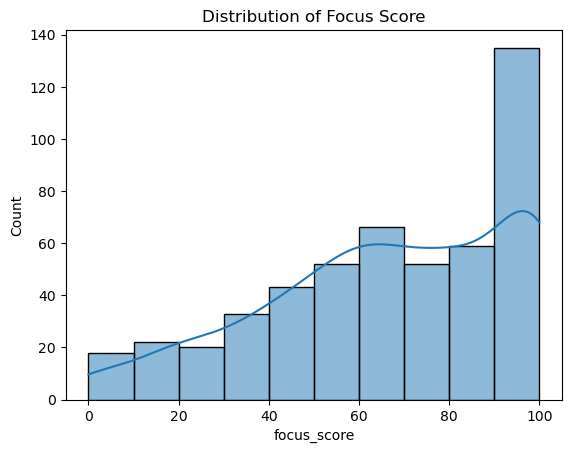

In [6]:
plt.figure()
sns.histplot(df["focus_score"], kde=True)
plt.title("Distribution of Focus Score")
plt.show()

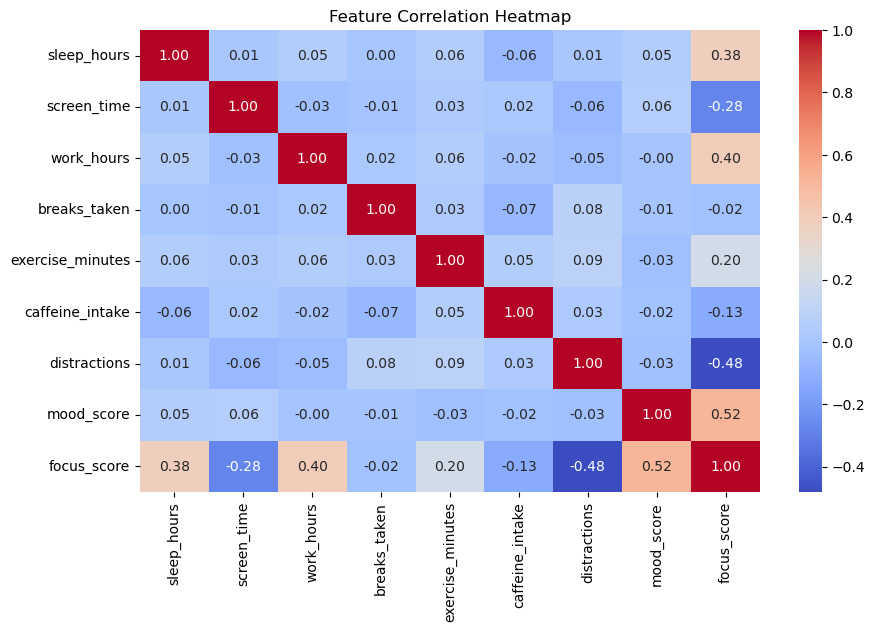

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

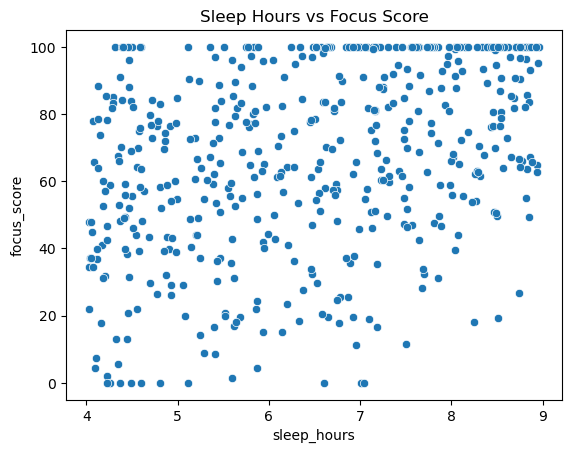

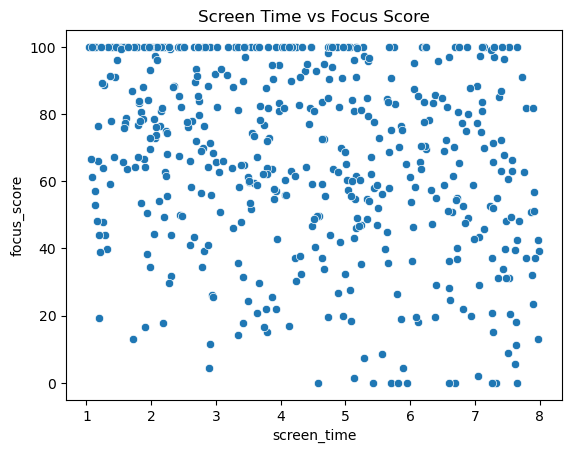

In [8]:
sns.scatterplot(x=df["sleep_hours"], y=df["focus_score"])
plt.title("Sleep Hours vs Focus Score")
plt.show()

sns.scatterplot(x=df["screen_time"], y=df["focus_score"])
plt.title("Screen Time vs Focus Score")
plt.show()

In [9]:
X = df.drop("focus_score", axis=1)
y = df["focus_score"]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

In [13]:
y_pred_lr = lr.predict(X_test_scaled)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression R²:", round(r2_lr, 3))
print("Linear Regression MAE:", round(mae_lr, 2))

Linear Regression R²: 0.938
Linear Regression MAE: 5.49


In [14]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [15]:
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest R²:", round(r2_rf, 3))
print("Random Forest MAE:", round(mae_rf, 2))

Random Forest R²: 0.838
Random Forest MAE: 8.7


In [16]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

mood_score          0.244739
distractions        0.211210
work_hours          0.205091
sleep_hours         0.146306
screen_time         0.089500
exercise_minutes    0.071912
breaks_taken        0.017024
caffeine_intake     0.014219
dtype: float64

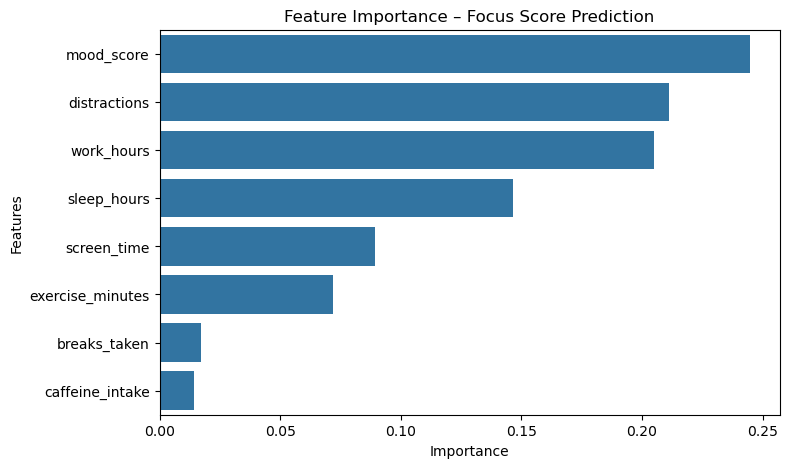

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance – Focus Score Prediction")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [18]:
def generate_recommendations(input_data):
    recommendations = []

    if input_data["sleep_hours"] < 6:
        recommendations.append("Increase sleep by at least 1 hour")

    if input_data["screen_time"] > 5:
        recommendations.append("Reduce screen time by 1–2 hours")

    if input_data["exercise_minutes"] < 20:
        recommendations.append("Add at least 20 minutes of exercise")

    if input_data["distractions"] > 5:
        recommendations.append("Reduce distractions during work hours")

    if input_data["mood_score"] < 5:
        recommendations.append("Improve mood via breaks, music, or social interaction")

    if not recommendations:
        recommendations.append("Great habits! Keep maintaining your routine")

    return recommendations

In [20]:
sample_input = {
    "sleep_hours": 8,
    "screen_time": 1,
    "work_hours": 5,
    "breaks_taken": 3,
    "exercise_minutes": 10,
    "caffeine_intake": 3,
    "distractions": 8,
    "mood_score": 4
}

predicted_focus = rf.predict(pd.DataFrame([sample_input]))[0]

print("Predicted Focus Score:", round(predicted_focus, 2))
print("Recommendations:")
for rec in generate_recommendations(sample_input):
    print("-", rec)

Predicted Focus Score: 70.76
Recommendations:
- Add at least 20 minutes of exercise
- Reduce distractions during work hours
- Improve mood via breaks, music, or social interaction


In [21]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [22]:
import streamlit as st
import pandas as pd
import pickle

# Load model
with open("model.pkl", "rb") as f:
    model = pickle.load(f)

st.set_page_config(page_title="FocusScoreML", page_icon="🧠", layout="centered")

st.title("🧠 FocusScoreML")
st.write("Predict your daily productivity and get actionable recommendations")

st.sidebar.header("Lifestyle Inputs")

sleep_hours = st.sidebar.slider("Sleep Hours", 4.0, 9.0, 7.0)
screen_time = st.sidebar.slider("Screen Time (hrs)", 1.0, 8.0, 4.0)
work_hours = st.sidebar.slider("Work Hours", 2.0, 10.0, 6.0)
breaks_taken = st.sidebar.slider("Breaks Taken", 0, 10, 3)
exercise_minutes = st.sidebar.slider("Exercise Minutes", 0.0, 90.0, 30.0)
caffeine_intake = st.sidebar.slider("Caffeine Intake (cups)", 0, 6, 2)
distractions = st.sidebar.slider("Distractions", 0, 15, 4)
mood_score = st.sidebar.slider("Mood Score", 1, 10, 7)

input_data = pd.DataFrame([{
    "sleep_hours": sleep_hours,
    "screen_time": screen_time,
    "work_hours": work_hours,
    "breaks_taken": breaks_taken,
    "exercise_minutes": exercise_minutes,
    "caffeine_intake": caffeine_intake,
    "distractions": distractions,
    "mood_score": mood_score
}])

def generate_recommendations(data):
    recs = []

    if data["sleep_hours"] < 6:
        recs.append("😴 Increase sleep by at least 1 hour")

    if data["screen_time"] > 5:
        recs.append("📵 Reduce screen time by 1–2 hours")

    if data["exercise_minutes"] < 20:
        recs.append("🏃 Add at least 20 minutes of exercise")

    if data["distractions"] > 5:
        recs.append("🎧 Reduce distractions during work hours")

    if data["mood_score"] < 5:
        recs.append("😊 Improve mood via breaks or social interaction")

    if not recs:
        recs.append("✅ Great habits! Keep it up")

    return recs

if st.button("Predict Focus Score"):
    prediction = model.predict(input_data)[0]

    st.subheader("🎯 Predicted Focus Score")
    st.metric(label="Focus Score", value=round(prediction, 2))

    st.subheader("🧠 Recommendations")
    for rec in generate_recommendations(input_data.iloc[0]):
        st.write(rec)

2026-01-31 20:23:35.822 
  command:

    streamlit run /opt/anaconda3/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]


In [23]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("model.pkl saved successfully")

model.pkl saved successfully


In [24]:
import os
print(os.getcwd())

/Users/user
